In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd

data_dir = '/content/drive/MyDrive/FundamentofDS/processed/binary'

X = np.load(os.path.join(data_dir, 'X_binary.npy'))
y = np.load(os.path.join(data_dir, 'y_binary.npy'))

df_meta = pd.read_csv(os.path.join(data_dir, 'metadata_binary.csv'))

train_mask = df_meta['strat_fold'] <= 8
val_mask   = df_meta['strat_fold'] == 9
test_mask  = df_meta['strat_fold'] == 10

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val     = X[val_mask], y[val_mask]
X_test, y_test   = X[test_mask], y[test_mask]

total = len(df_meta)
print(f"Train: {len(X_train)} samples ({len(X_train)/total*100:.1f}%)")
print(f"Val:   {len(X_val)} samples ({len(X_val)/total*100:.1f}%)")
print(f"Test:  {len(X_test)} samples ({len(X_test)/total*100:.1f}%)")

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"Unique y_train labels: {np.unique(y_train)}")

Train: 17418 samples (79.9%)
Val:   2183 samples (10.0%)
Test:  2198 samples (10.1%)
X_train shape: (17418, 1000, 12), y_train shape: (17418,)
Unique y_train labels: [0 1]


In [ ]:
np.save(os.path.join(data_dir, 'X_train.npy'), X_train)
np.save(os.path.join(data_dir, 'y_train.npy'), y_train)

np.save(os.path.join(data_dir, 'X_val.npy'), X_val)
np.save(os.path.join(data_dir, 'y_val.npy'), y_val)

np.save(os.path.join(data_dir, 'X_test.npy'), X_test)
np.save(os.path.join(data_dir, 'y_test.npy'), y_test)

In [ ]:
X_train = np.transpose(X_train, (0, 2, 1))
X_val   = np.transpose(X_val, (0, 2, 1))
X_test  = np.transpose(X_test, (0, 2, 1))

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (17418, 12, 1000)
X_val shape: (2183, 12, 1000)
X_test shape: (2198, 12, 1000)


In [ ]:
!git clone https://github.com/hsd1503/resnet1d.git

Cloning into 'resnet1d'...
remote: Enumerating objects: 238, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 238 (delta 44), reused 40 (delta 40), pack-reused 190 (from 1)
Receiving objects: 100% (238/238), 11.89 MiB | 31.62 MiB/s, done.
Resolving deltas: 100% (137/137), done.


In [ ]:
import sys
sys.path.append('/content/resnet1d')

from resnet1d.resnet1d import ResNet1D

In [ ]:
print(ResNet1D)

<class 'resnet1d.resnet1d.ResNet1D'>


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor   = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor   = torch.tensor(y_val, dtype=torch.float32)

num_samples, in_channels, seq_len = X_train_tensor.shape
print(f"Dataset summary: {num_samples} samples | {in_channels} channels | {seq_len} sequence length")

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)

train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader    = DataLoader(val_dataset, batch_size=32, shuffle=False)

Dataset summary: 17418 samples | 12 channels | 1000 sequence length


In [ ]:
model = ResNet1D(
    in_channels=12,
    base_filters=64,
    kernel_size=16,
    stride=2,
    groups=1,
    n_classes=1,
    n_block=4
).to(device)

In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

In [ ]:
model = model.to(device)

In [ ]:
num_epochs = 30
best_val_loss = float('inf')

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device).float()

        optimizer.zero_grad()

        outputs = model(inputs).squeeze(-1)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        preds = (outputs >= 0.0).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = (correct / total) * 100

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device).float()

            outputs = model(inputs).squeeze(-1)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            preds = (outputs >= 0.0).float()
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss / val_total
    val_acc = (val_correct / val_total) * 100

    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1:02d}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_resnet1d_model.pth')
        print(f"   --> Saved new best model with Val Loss: {val_loss:.4f}")

print(f"Training completed! Best Val Loss achieved: {best_val_loss:.4f}")
print("Best weights saved to: 'best_resnet1d_model.pth'")

Epoch [01/30] | Train Loss: 0.3618 | Train Acc: 83.38% | Val Loss: 0.3498 | Val Acc: 84.10%
   --> Saved new best model with Val Loss: 0.3498
Epoch [02/30] | Train Loss: 0.3315 | Train Acc: 85.36% | Val Loss: 0.3502 | Val Acc: 83.55%
Epoch [03/30] | Train Loss: 0.3181 | Train Acc: 86.07% | Val Loss: 0.3379 | Val Acc: 84.70%
   --> Saved new best model with Val Loss: 0.3379
Epoch [04/30] | Train Loss: 0.3114 | Train Acc: 86.35% | Val Loss: 0.3489 | Val Acc: 85.02%
Epoch [05/30] | Train Loss: 0.3052 | Train Acc: 86.75% | Val Loss: 0.3319 | Val Acc: 85.25%
   --> Saved new best model with Val Loss: 0.3319
Epoch [06/30] | Train Loss: 0.3020 | Train Acc: 86.95% | Val Loss: 0.3367 | Val Acc: 85.20%
Epoch [07/30] | Train Loss: 0.2971 | Train Acc: 87.18% | Val Loss: 0.3470 | Val Acc: 84.61%
Epoch [08/30] | Train Loss: 0.2922 | Train Acc: 87.40% | Val Loss: 0.3527 | Val Acc: 85.11%
Epoch [09/30] | Train Loss: 0.2879 | Train Acc: 87.41% | Val Loss: 0.3333 | Val Acc: 85.30%
Epoch [10/30] | Train 

In [ ]:
!git clone https://github.com/liguge/1D-Grad-CAM-for-interpretable-intelligent-fault-diagnosis.git

Cloning into '1D-Grad-CAM-for-interpretable-intelligent-fault-diagnosis'...
remote: Enumerating objects: 297, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 297 (delta 41), reused 1 (delta 0), pack-reused 231 (from 1)
Receiving objects: 100% (297/297), 76.00 KiB | 1.81 MiB/s, done.
Resolving deltas: 100% (183/183), done.


In [ ]:
import matplotlib.pyplot as plt

%matplotlib inline

sys.path.append('./1D-Grad-CAM-for-interpretable-intelligent-fault-diagnosis')

def get_1d_gradcam(model, input_tensor, target_layer):
    model.eval()
    gradients = []
    activations = []

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    def forward_hook(module, input, output):
        activations.append(output)

    h_f = target_layer.register_forward_hook(forward_hook)
    h_b = target_layer.register_full_backward_hook(backward_hook)

    model.zero_grad()
    output = model(input_tensor).squeeze(-1)

    if output.ndim > 0:
        score = output.squeeze()
    else:
        score = output
    score.backward(retain_graph=True)

    h_f.remove()
    h_b.remove()

    grads = gradients[0]
    acts = activations[0]

    weights = torch.mean(grads, dim=-1, keepdim=True)

    cam = torch.sum(weights * acts, dim=1, keepdim=True)
    cam = torch.relu(cam)

    cam = torch.nn.functional.interpolate(
        cam,
        size=input_tensor.shape[-1],
        mode='linear',
        align_corners=False
    )

    cam_mask = cam.squeeze().cpu().detach().numpy()
    if cam_mask.max() != 0:
        cam_mask = cam_mask / cam_mask.max()

    return cam_mask

LABEL_NAMES = {0: "Normal", 1: "Abnormal"}

In [ ]:
def predict_and_explain(patient_idx, X_data, y_data, model, target_layer, device='cuda'):
    model.eval()

    sample_ecg = X_data[patient_idx:patient_idx+1]
    true_label = int(y_data[patient_idx])

    input_tensor = torch.tensor(sample_ecg, dtype=torch.float32).to(device)

    with torch.no_grad():
        output = model(input_tensor).squeeze(-1)
        prob = torch.sigmoid(output).item()

    pred_label = 1 if prob >= 0.5 else 0

    cam_mask = get_1d_gradcam(model, input_tensor, target_layer)
    cam_mask = cam_mask * prob
    return {
        'idx': patient_idx,
        'input_tensor': input_tensor,
        'true_label': true_label,
        'pred_label': pred_label,
        'prob': prob,
        'cam_mask': cam_mask
    }

In [ ]:
def plot_ecg_gradcam(res, lead_idx=1, lead_name='Lead II'):
    signal = res['input_tensor'][0, lead_idx].cpu().numpy()

    print(f"Ground Truth : {LABEL_NAMES[res['true_label']]}")
    print(f"Prediction   : {LABEL_NAMES[res['pred_label']]}")
    print(f"Abnormal Prob: {res['prob'] * 100:.1f}%")

    plt.figure(figsize=(14, 4))
    plt.plot(signal, color='black', linewidth=1.2, label=f'ECG {lead_name}')

    plt.imshow(
        res['cam_mask'][np.newaxis, :],
        cmap='Reds',
        aspect='auto',
        extent=[0, len(signal), signal.min() - 0.2, signal.max() + 0.2],
        alpha=0.8,
        vmin=0.0,
        vmax=1.0
    )

    plt.colorbar(label='Grad-CAM Attention Weight')
    plt.title(
        f"Patient #{res['idx']} | True: {LABEL_NAMES[res['true_label']]} | "
        f"Pred: {LABEL_NAMES[res['pred_label']]} ({res['prob']*100:.1f}%)",
        fontsize=12, fontweight='bold'
    )
    plt.xlabel('Time steps')
    plt.ylabel('Amplitude')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

Ground Truth : Abnormal
Prediction   : Abnormal
Abnormal Prob: 96.8%


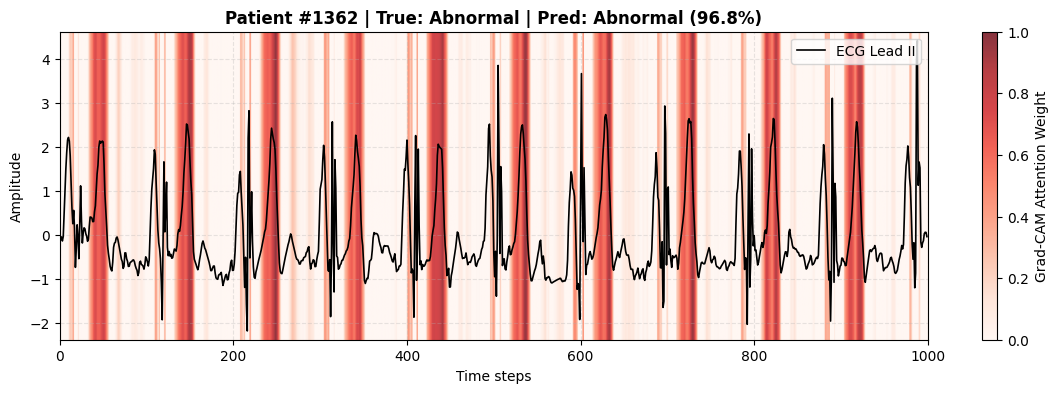

In [ ]:
target_layer = model.first_block_conv

random_idx = np.random.randint(0, len(X_test))

results = predict_and_explain(
    patient_idx=random_idx,
    X_data=X_test,
    y_data=y_test,
    model=model,
    target_layer=target_layer,
    device=device
)

plot_ecg_gradcam(results, lead_idx=1, lead_name='Lead II')

In [ ]:
from sklearn.metrics import classification_report

def get_classification_report(model, X_test, y_test, device='cuda', threshold=0.5):
    model.eval()

    inputs = torch.tensor(X_test, dtype=torch.float32).to(device)

    with torch.no_grad():
        outputs = model(inputs).squeeze(-1)
        probs = torch.sigmoid(outputs).cpu().numpy()

    preds = (probs >= threshold).astype(int)
    y_true = y_test.astype(int)

    print(" CLASSIFICATION REPORT ".center(60, "="))
    print(classification_report(
        y_true,
        preds,
        target_names=['Normal (0)', 'Abnormal (1)'],
        digits=4
    ))

    return y_true, preds, probs

y_true, preds, probs = get_classification_report(model, X_test, y_test, device=device)

================== CLASSIFICATION REPORT ===================
              precision    recall  f1-score   support

  Normal (0)     0.7992    0.8821    0.8386       916
Abnormal (1)     0.9090    0.8417    0.8740      1282

    accuracy                         0.8585      2198
   macro avg     0.8541    0.8619    0.8563      2198
weighted avg     0.8633    0.8585    0.8593      2198



ROC-AUC Score : 0.9331
Specificity   : 88.21%


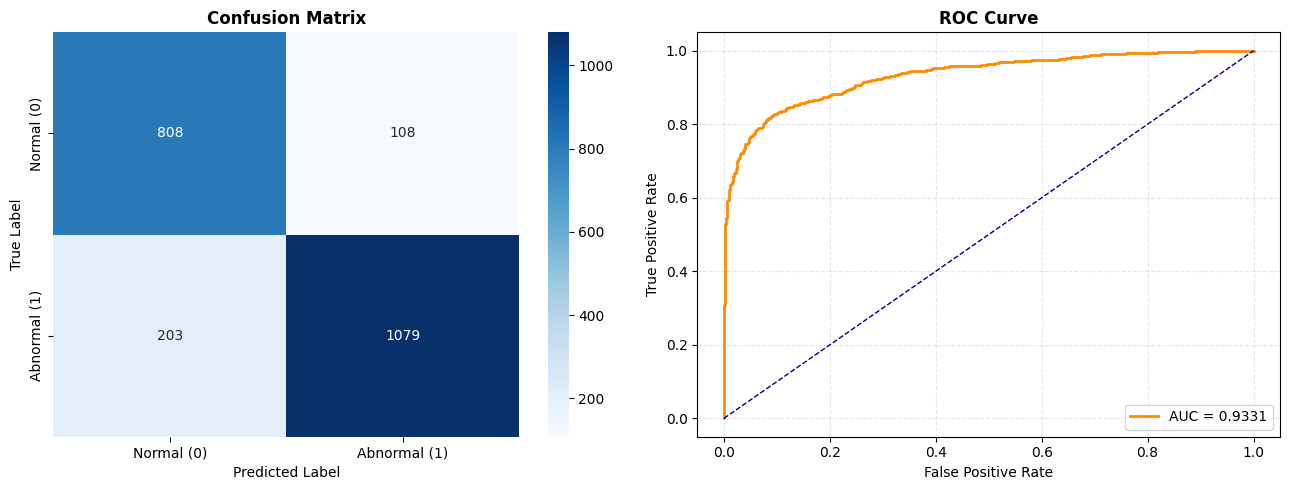

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

def plot_extended_metrics_and_plots(y_true, preds, probs):
    auc = roc_auc_score(y_true, probs)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    print(f"ROC-AUC Score : {auc:.4f}")
    print(f"Specificity   : {specificity * 100:.2f}%")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    sns.heatmap(
        [[tn, fp], [fn, tp]],
        annot=True, fmt='d', cmap='Blues', ax=axes[0],
        xticklabels=['Normal (0)', 'Abnormal (1)'],
        yticklabels=['Normal (0)', 'Abnormal (1)']
    )
    axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    fpr, tpr, _ = roc_curve(y_true, probs)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc:.4f}')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc='lower right')
    axes[1].grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_extended_metrics_and_plots(y_true, preds, probs)

In [ ]:
def extract_gradcam_sample_indices(y_true, preds):
    fn_indices = np.where((y_true == 1) & (preds == 0))[0]
    fp_indices = np.where((y_true == 0) & (preds == 1))[0]
    tp_indices = np.where((y_true == 1) & (preds == 1))[0]

    print(" GRAD-CAM SAMPLE INDICES ".center(60, "="))
    print(f"- False Negative Indices (Missed Abnormalities) : {list(fn_indices[:5])}")
    print(f"- True Positive Indices (Correct Predictions)   : {list(tp_indices[:5])}")
    print(f"- False Positive Indices (False Alarms)         : {list(fp_indices[:5])}")

    return fn_indices, tp_indices, fp_indices

fn_idx, tp_idx, fp_idx = extract_gradcam_sample_indices(y_true, preds)

================= GRAD-CAM SAMPLE INDICES ==================
- False Negative Indices (Missed Abnormalities) : [np.int64(5), np.int64(14), np.int64(32), np.int64(33), np.int64(48)]
- True Positive Indices (Correct Predictions)   : [np.int64(6), np.int64(19), np.int64(22), np.int64(23), np.int64(24)]
- False Positive Indices (False Alarms)         : [np.int64(37), np.int64(103), np.int64(105), np.int64(149), np.int64(152)]


In [ ]:
import shutil

shutil.copy('best_resnet1d_model.pth', '/content/drive/MyDrive/FundamentofDS/processed/resnet1d_binary_labels.pt')

'/content/drive/MyDrive/FundamentofDS/processed/resnet1d_binary_labels.pt'